In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from src.fluid      import Fluid
from src.interpolator import LinearInterpolator
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

plt.rcParams['axes.grid'] = True

In [3]:
M = 0.016
T_res = 310.0
df = pd.read_csv('hw2_data.csv', sep=';')
xa = df['xa, mol. %'].iloc[15] / 100
xy = df['xy, mol. %'].iloc[15] / 100
rho_c = df['rho_c, kg/m3'].iloc[15]

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

In [4]:
import math
roughness = 0.000046  # m

# Пласт (общий для всех трёх скважин)
P0    = 100.0   # atm
V_res = math.pi * 500**2 * 25   # m³

# NKT Скважины
nkt_1 = Pipe(L=2000, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1800)
nkt_2 = Pipe(L=2500, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1900)
nkt_3 = Pipe(L=1800, D=0.073, roughness=roughness, fluid=fluid, vertical_depth=1600)

# Скважины: [k, h, re, rw]
well_1 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_1)
well_2 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_2)
well_3 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_3)
wells = [well_1, well_2, well_3]

# Шлейф
shlyf = Pipe(L=5000, D=0.200, roughness=roughness, fluid=fluid, vertical_depth=0)

# ДКС
CR     = 1.5
P_line = 5.0    # atm
q_ext  = 500.0  # ст.м³/сут
dcs   = DCS(CR=CR, P_line=P_line, q_ext=q_ext)

resprops = ResProps(P=P0, V=V_res, T=T_res)
reservoir = Reservoir(resprops=resprops, fluid=fluid)
simulate = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

# Раздел 1 — Модель PVT

Графики Z(P), Bg(P), mu(P), ρ(P) в диапазоне 1–200 атм.

Сравнение ρ_ideal vs ρ_real

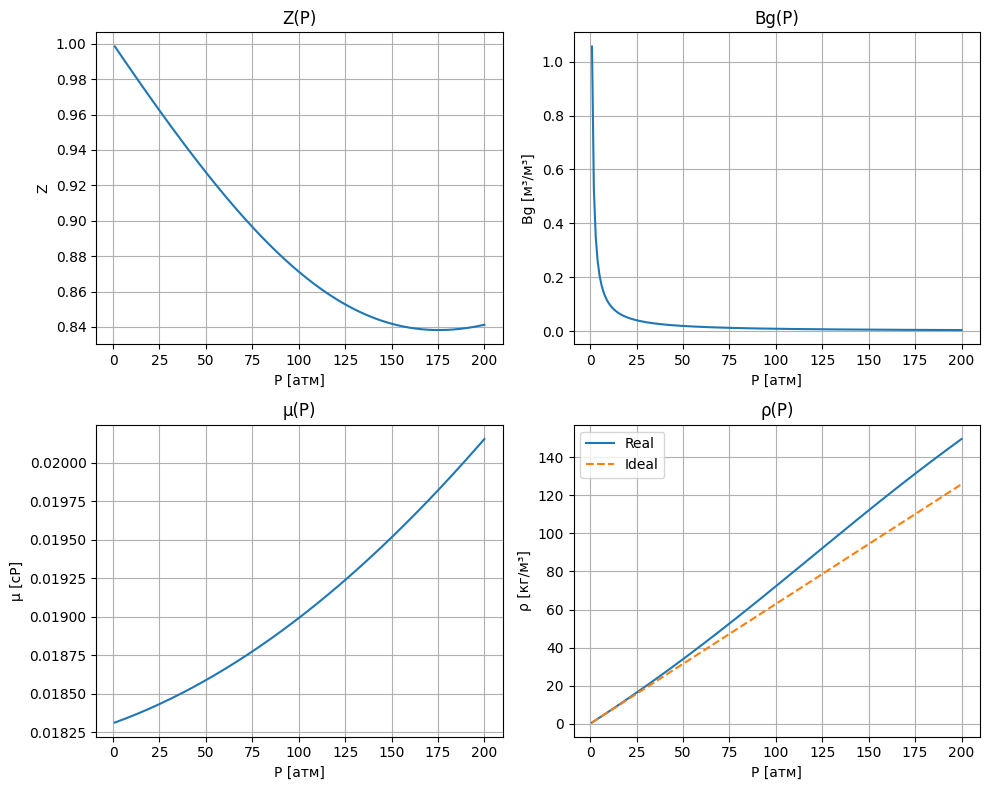

In [5]:
P_range = np.linspace(1, 200, 200)

Z_vals   = [fluid.z(P)   for P in P_range]
Bg_vals  = [fluid.bg(P)  for P in P_range]
mu_vals  = [fluid.mu(P)  for P in P_range]
rho_vals = [fluid.ro(P)  for P in P_range]

R = 8.314
rho_ideal = [P * 101325 * M / (1.0 * R * T_res) for P in P_range]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Графики Z(P), Bg(P), mu(P)
axes[0,0].plot(P_range, Z_vals);   axes[0,0].set(title='Z(P)', xlabel='P [атм]', ylabel='Z')
axes[0,1].plot(P_range, Bg_vals);  axes[0,1].set(title='Bg(P)', xlabel='P [атм]', ylabel='Bg [м³/м³]')
axes[1,0].plot(P_range, mu_vals);  axes[1,0].set(title='μ(P)', xlabel='P [атм]', ylabel='μ [cP]')
#ρ(P), cравнение ρ_ideal vs ρ_real
axes[1,1].plot(P_range, rho_vals, label='Real')
axes[1,1].plot(P_range, rho_ideal, '--', label='Ideal')
axes[1,1].set(title='ρ(P)', xlabel='P [атм]', ylabel='ρ [кг/м³]')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Раздел 2 — Модель пласта

кривая IPR при P_res = 100 атм для одной скважины.

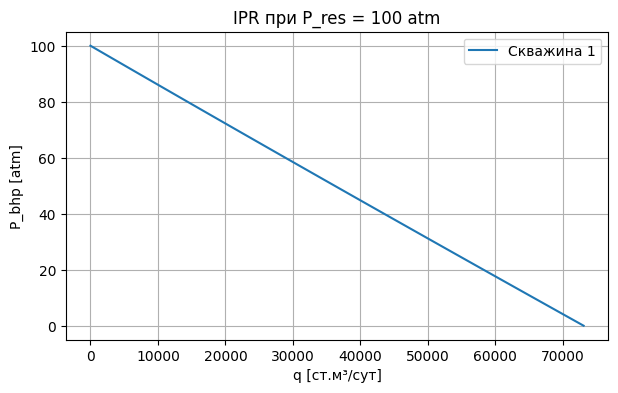

In [6]:
P_res = 100
P_bhp_range = np.linspace(0, P_res, 100)
q_ipr = [well_1.q(P_res, P_bhp) for P_bhp in P_bhp_range]

fig, axes = plt.subplots(figsize=(7, 4))
axes.plot(q_ipr, P_bhp_range, label=f'Скважина 1')
axes.set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]',
       title=f'IPR при P_res = {P_res} atm')
axes.legend()
plt.show()

# Раздел 3 — Гидравлика

кривые VLP трёх скважин и шлейфа. Зависимость λ(Re) по Колбруку–Уайту.

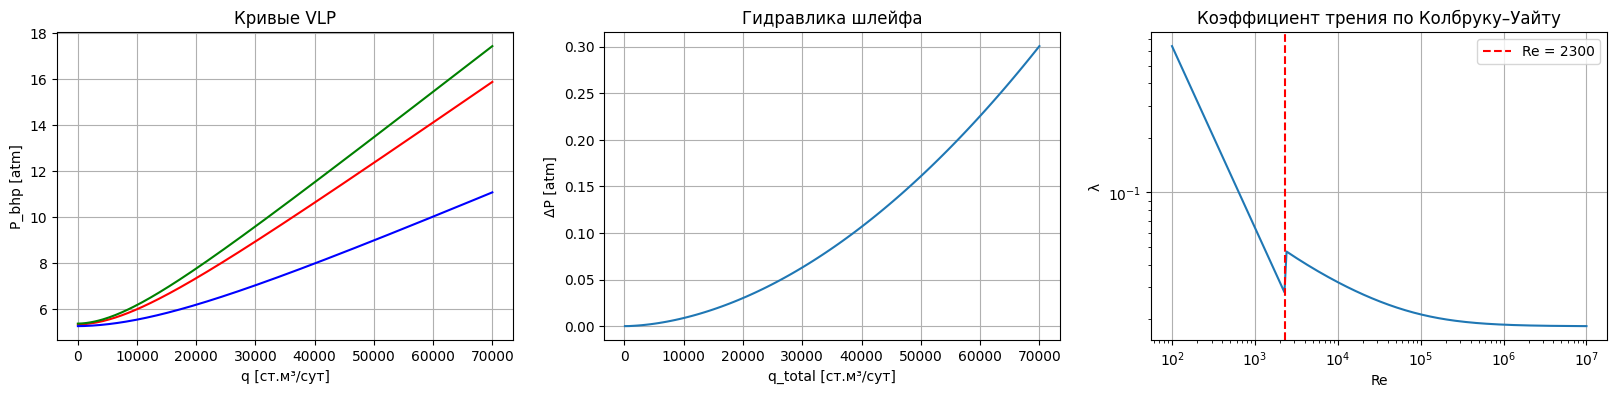

In [52]:
P0 = 100.0
q_range = np.linspace(10, 70000, 200)
states_0 = simulate.solve(P_res=P0)

# --- Скважина 1 ---
P_bhp_1 = states_0['well_1'].P_in
P_man_1 = states_0['well_1'].P_out

# --- Скважина 2 ---
P_bhp_2 = states_0['well_2'].P_in
P_man_2 = states_0['well_2'].P_out

# --- Скважина 3 ---
P_bhp_3 = states_0['well_3'].P_in
P_man_3 = states_0['well_3'].P_out

def calc_vlp(pipe: Pipe, P_man: float, q: float, tol: float = 1e-6, max_iter: int = 50) -> float:
    """
    Вычисляет P_bhp для заданного q и P_man, итерируя падение давления в НКТ.
    """
    P_bhp = P_man
    for _ in range(max_iter):
        deltaP = pipe.dp(P_bhp, q)
        P_bhp_new = P_man + deltaP.dP
        if abs(P_bhp_new - P_bhp) < tol:
            return P_bhp_new
        P_bhp = P_bhp_new
    return P_bhp

# Кривые VLP (физически корректные)
P_bhp_vlp_1 = [calc_vlp(nkt_1, P_man_1, q) for q in q_range]
P_bhp_vlp_2 = [calc_vlp(nkt_2, P_man_2, q) for q in q_range]
P_bhp_vlp_3 = [calc_vlp(nkt_3, P_man_3, q) for q in q_range]

fig, axes = plt.subplots(1,3, figsize=(20, 4) )
axes[0].plot(q_range, P_bhp_vlp_1, 'r-', label='Скважина 1')
axes[0].plot(q_range, P_bhp_vlp_2, 'g-', label='Скважина 2')
axes[0].plot(q_range, P_bhp_vlp_3, 'b-', label='Скважина 3')
axes[0].set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]', title='Кривые VLP')

# VLP шлейфа
q_shlyf = np.linspace(100, 70000, 100)
dP_shlyf = [shlyf.dp(dcs.P_in(), q).dP for q in q_shlyf]

axes[1].plot(q_shlyf, dP_shlyf)
axes[1].set(xlabel='q_total [ст.м³/сут]', ylabel='ΔP [atm]', title='Гидравлика шлейфа')

# λ(Re)
Re_range = np.logspace(2, 7, 200)
lambda_vals = [nkt_1.f_lambda(Re) for Re in Re_range]

axes[2].loglog(Re_range, lambda_vals)
axes[2].axvline(2300, color='r', linestyle='--', label='Re = 2300')
axes[2].set(xlabel='Re', ylabel='λ', title='Коэффициент трения по Колбруку–Уайту')

plt.legend(); plt.show()

# Раздел 4 — Рабочая точка

графики IPR + VLP для каждой скважины с отмеченной рабочей точкой.

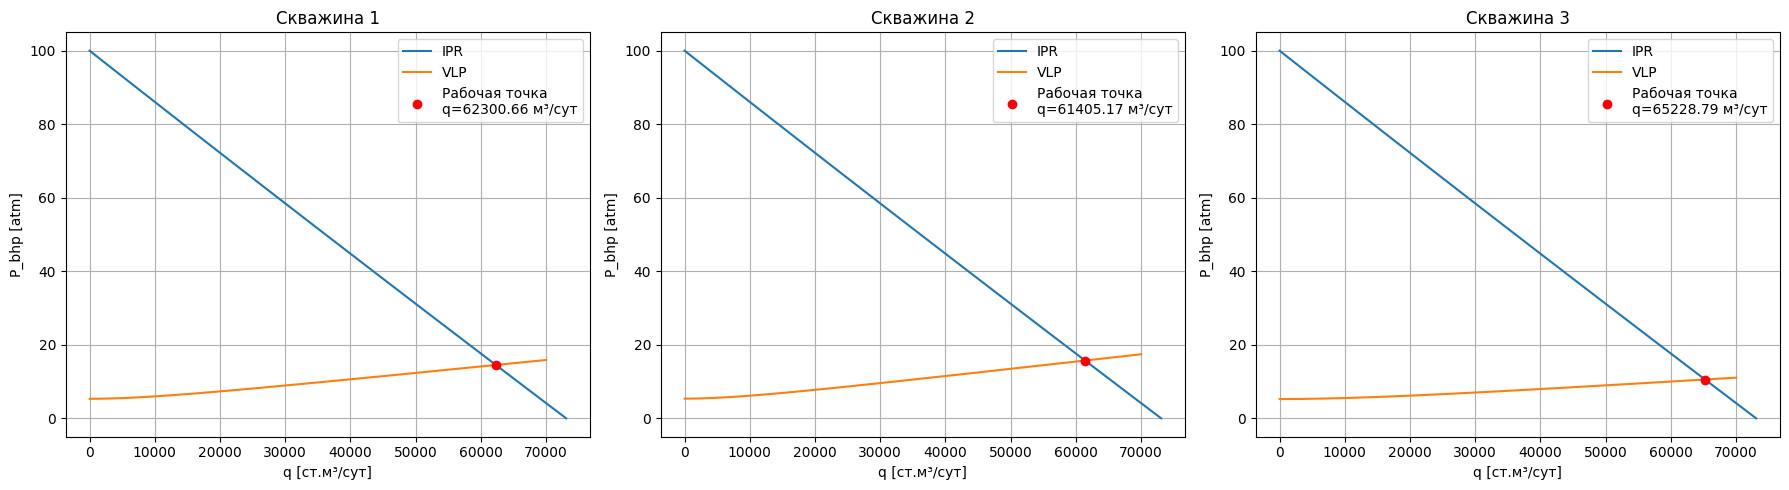

In [48]:
P_bhp_range = np.linspace(0, P0, 100)
fig, axes = plt.subplots(1,3, figsize=(18, 5))

# --- Скважина 1 ---
q_1 = states_0['well_1'].q_std
q_ipr_1 = [well_1.q(P0, Pb) for Pb in P_bhp_range]

axes[0].plot(q_ipr_1, P_bhp_range, label='IPR')
axes[0].plot(q_range, P_bhp_vlp_1, label='VLP')
axes[0].scatter([q_1], [P_bhp_1], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_1:0.2f} м³/сут')
axes[0].set(title='Скважина 1', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[0].legend()

# --- Скважина 2 ---
q_2 = states_0['well_2'].q_std
q_ipr_2 = [well_2.q(P0, Pb) for Pb in P_bhp_range]

axes[1].plot(q_ipr_2, P_bhp_range, label='IPR')
axes[1].plot(q_range, P_bhp_vlp_2, label='VLP')
axes[1].scatter([q_2], [P_bhp_2], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_2:0.2f} м³/сут')
axes[1].set(title='Скважина 2', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[1].legend()

# --- Скважина 3 ---
q_3 = states_0['well_3'].q_std
q_ipr_3 = [well_3.q(P0, Pb) for Pb in P_bhp_range]

axes[2].plot(q_ipr_3, P_bhp_range, label='IPR')
axes[2].plot(q_range, P_bhp_vlp_3, label='VLP')
axes[2].scatter([q_3], [P_bhp_3], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_3:0.2f} м³/сут')
axes[2].set(title='Скважина 3', xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]')
axes[2].legend()

plt.tight_layout()
plt.show()

# Раздел 5 — Динамика 

графики Pres(t), Pman(t), q1(t), q2(t), q3(t), Gp(t) на 180 дней.

ЗАПУСК СИМУЛЯЦИИ
День   1 | P_res = 100.00 атм | q_total = 188934.63 ст.м³/сут | Gp = 188.9 тыс. м³
День  10 | P_res = 100.00 атм | q_total = 188932.04 ст.м³/сут | Gp = 1889.3 тыс. м³
День  20 | P_res = 100.00 атм | q_total = 188929.15 ст.м³/сут | Gp = 3778.6 тыс. м³
День  30 | P_res = 100.00 атм | q_total = 188926.27 ст.м³/сут | Gp = 5667.9 тыс. м³
День  40 | P_res = 100.00 атм | q_total = 188923.39 ст.м³/сут | Gp = 7557.2 тыс. м³
День  50 | P_res = 100.00 атм | q_total = 188920.51 ст.м³/сут | Gp = 9446.4 тыс. м³
День  60 | P_res = 100.00 атм | q_total = 188917.63 ст.м³/сут | Gp = 11335.6 тыс. м³
День  70 | P_res =  99.99 атм | q_total = 188914.75 ст.м³/сут | Gp = 13224.7 тыс. м³
День  80 | P_res =  99.99 атм | q_total = 188911.87 ст.м³/сут | Gp = 15113.9 тыс. м³
День  90 | P_res =  99.99 атм | q_total = 188908.99 ст.м³/сут | Gp = 17003.0 тыс. м³
День 100 | P_res =  99.99 атм | q_total = 188906.11 ст.м³/сут | Gp = 18892.0 тыс. м³
День 110 | P_res =  99.99 атм | q_total = 188903.23 ст.

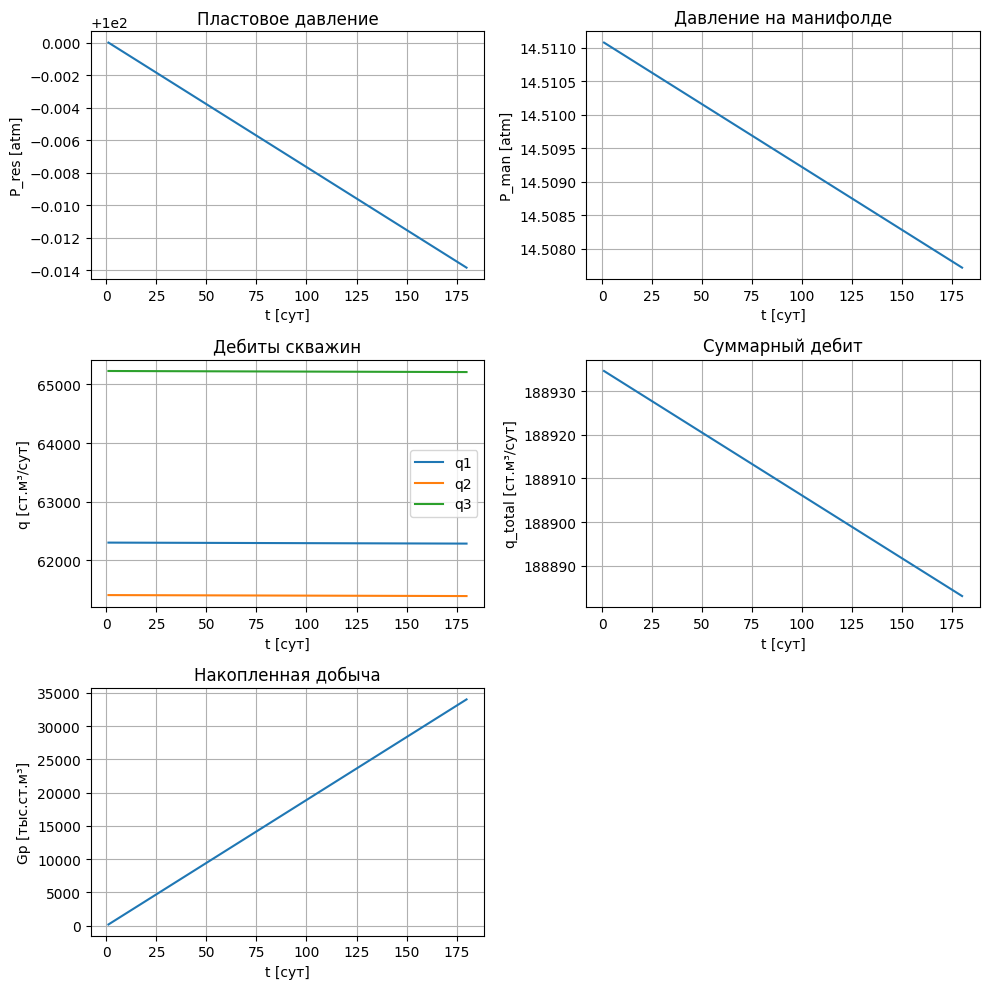

In [47]:
reservoir.resprops.P = P0

df = simulate.run(N_days=180, dt=1.0)

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

axes[0,0].plot(df['t'], df['P_res'])
axes[0,0].set(ylabel='P_res [atm]', title='Пластовое давление')

axes[0,1].plot(df['t'], df['P_man'])
axes[0,1].set(ylabel='P_man [atm]', title='Давление на манифолде')

axes[1,0].plot(df['t'], df['q1'], label='q1')
axes[1,0].plot(df['t'], df['q2'], label='q2')
axes[1,0].plot(df['t'], df['q3'], label='q3')
axes[1,0].set(ylabel='q [ст.м³/сут]', title='Дебиты скважин')
axes[1,0].legend()

axes[1,1].plot(df['t'], df['q_total']); 
axes[1,1].set(ylabel='q_total [ст.м³/сут]', title='Суммарный дебит')

axes[2,0].plot(df['t'], df['Gp'])
axes[2,0].set(ylabel='Gp [тыс.ст.м³]', title='Накопленная добыча')

axes[2,1].axis('off')

for ax in axes.flat:
    ax.set_xlabel('t [сут]')
plt.tight_layout(); plt.show()

# Раздел 6 — Влияние ДКС

сравнение динамики при CR ∈ 1.0, 1.5, 2.0, 3.0.


ЗАПУСК СИМУЛЯЦИИ
День   1 | P_res = 100.00 атм | q_total = 187013.41 ст.м³/сут | Gp = 187.0 тыс. м³
День  10 | P_res = 100.00 атм | q_total = 187010.85 ст.м³/сут | Gp = 1870.1 тыс. м³
День  20 | P_res = 100.00 атм | q_total = 187008.00 ст.м³/сут | Gp = 3740.2 тыс. м³
День  30 | P_res = 100.00 атм | q_total = 187005.16 ст.м³/сут | Gp = 5610.3 тыс. м³
День  40 | P_res = 100.00 атм | q_total = 187002.31 ст.м³/сут | Gp = 7480.3 тыс. м³
День  50 | P_res = 100.00 атм | q_total = 186999.46 ст.м³/сут | Gp = 9350.3 тыс. м³
День  60 | P_res = 100.00 атм | q_total = 186996.61 ст.м³/сут | Gp = 11220.3 тыс. м³
День  70 | P_res =  99.99 атм | q_total = 186993.77 ст.м³/сут | Gp = 13090.3 тыс. м³
День  80 | P_res =  99.99 атм | q_total = 186990.92 ст.м³/сут | Gp = 14960.2 тыс. м³
День  90 | P_res =  99.99 атм | q_total = 186988.07 ст.м³/сут | Gp = 16830.1 тыс. м³
День 100 | P_res =  99.99 атм | q_total = 186985.22 ст.м³/сут | Gp = 18699.9 тыс. м³
День 110 | P_res =  99.99 атм | q_total = 186982.38 ст.

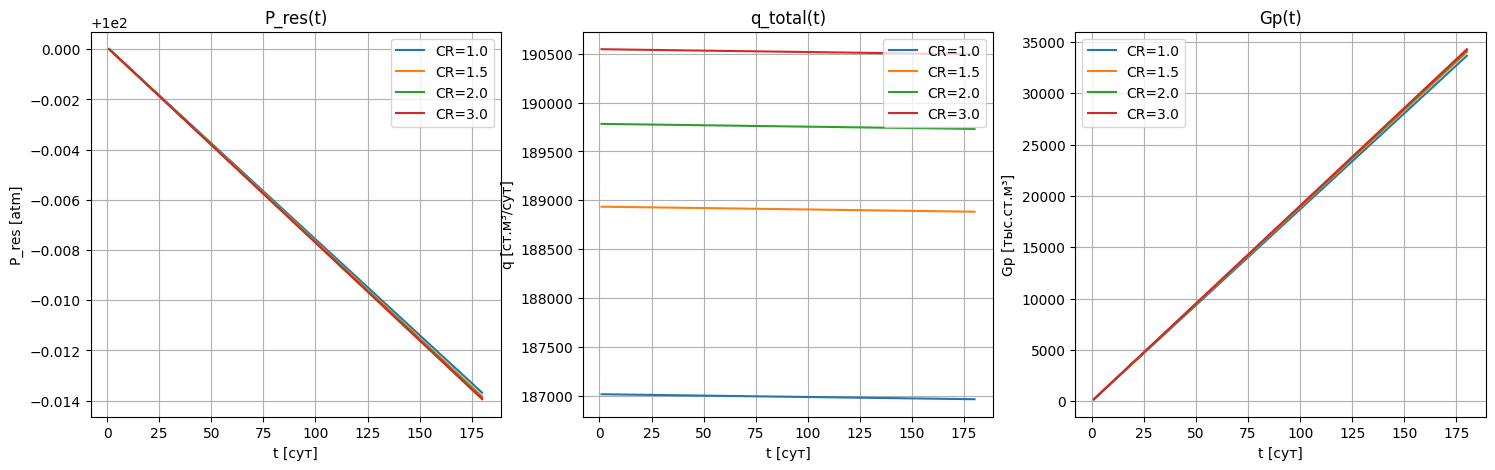

In [10]:
CR_values = [1.0, 1.5, 2.0, 3.0]
results_cr = {}

for cr in CR_values:
    reservoir.resprops.P = P0
    dcs.CR = cr
    df_cr = simulate.run(N_days=180, dt=1.0)
    results_cr[cr] = df_cr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cr, df_cr in results_cr.items():
    axes[0].plot(df_cr['t'], df_cr['P_res'],   label=f'CR={cr}')
    axes[1].plot(df_cr['t'], df_cr['q_total'], label=f'CR={cr}')
    axes[2].plot(df_cr['t'], df_cr['Gp'],      label=f'CR={cr}')

axes[0].set(title='P_res(t)', xlabel='t [сут]', ylabel='P_res [atm]')
axes[1].set(title='q_total(t)', xlabel='t [сут]', ylabel='q [ст.м³/сут]')
axes[2].set(title='Gp(t)', xlabel='t [сут]', ylabel='Gp [тыс.ст.м³]')
for ax in axes: 
    ax.legend()
plt.show()

dcs.CR = CR

# Раздел 7 — Калибровка

график «факт vs модель» по данным adapt_gdi_11-2025.csv, значения R² и RMSE.

C оптимальный: 23230.2630
R² = 0.9709
RMSE = 2499.69 ст.м³/сут


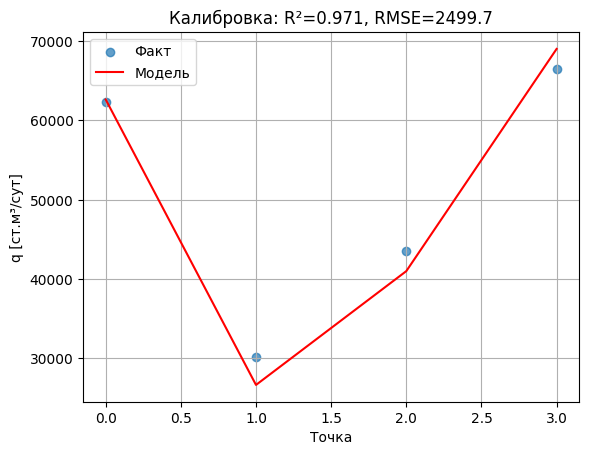

In [11]:
# Промысловые данные
df_fact    = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')
q_fact     = df_fact['q'].values
P_res_fact = df_fact['p_res'].values
P_bhp_fact = df_fact['p_bhp'].values

# Функция ошибки
def calculate_rmse(X):
    C = X[0]
    q_model = C * (P_res_fact - P_bhp_fact)
    return np.sqrt(np.mean((q_model - q_fact)**2))

# Оптимизация
result = minimize(calculate_rmse, x0=[1.0], method='Nelder-Mead')
C_opt     = result.x[0]
print(f'C оптимальный: {C_opt:.4f}')

q_opt = C_opt * (P_res_fact - P_bhp_fact)
ss_res = np.sum((q_fact - q_opt)**2)
ss_tot = np.sum((q_fact - np.mean(q_fact))**2)
R2   = 1 - ss_res / ss_tot
RMSE = np.sqrt(np.mean((q_fact - q_opt)**2))
print(f'R² = {R2:.4f}')
print(f'RMSE = {RMSE:.2f} ст.м³/сут')

fig, axes = plt.subplots()
axes.scatter(range(len(q_fact)), q_fact, label='Факт',   alpha=0.7)
axes.plot(   range(len(q_opt)),  q_opt,  label='Модель', color='red')
axes.set(xlabel='Точка', ylabel='q [ст.м³/сут]',
       title=f'Калибровка: R²={R2:.3f}, RMSE={RMSE:.1f}')
axes.legend()
plt.show()

Диапазон q:     30149 – 66510 м³/сут
Диапазон P_res: 81.78 – 81.78 атм
Диапазон P_bhp: 51.67 – 70.15 атм
Диапазон ΔP:    11.63 – 30.11 атм

C теоретический (по Дарси): 66.4607
C оптимальный: 2292.6487
Отношение C_opt / C_teor: 34.50
R² = 0.9709
RMSE = 2499.69 м³/сут


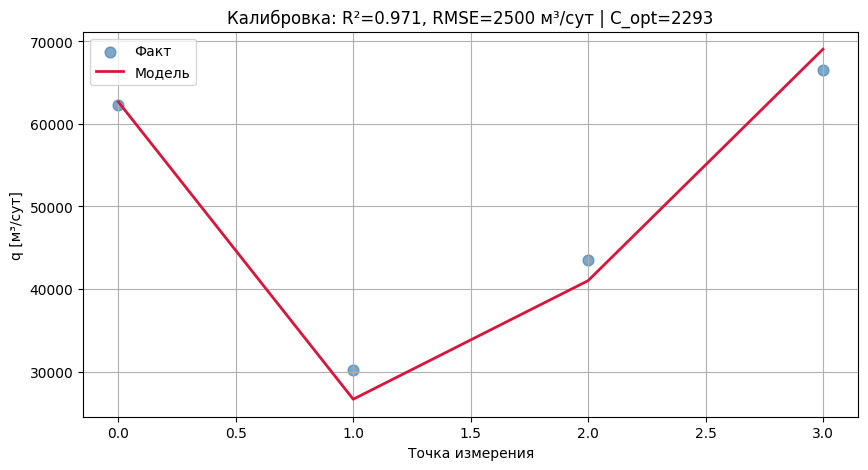

In [19]:
# Sección 7 — Калибровка по промысловым данным

# 1. Читаем данные (предполагаем: p в MPa, q в м³/сут)
df_fact = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')

# 2. Конверсия единиц: 1 MPa ≈ 10.1325 атм
MPa_to_atm = 10.1325

q_fact     = df_fact['q'].values
P_res_fact = df_fact['p_res'].values * MPa_to_atm
P_bhp_fact = df_fact['p_bhp'].values * MPa_to_atm
P_thp_fact = df_fact['p_thp'].values * MPa_to_atm   # для строгой калибровки по VLP

print(f"Диапазон q:     {q_fact.min():.0f} – {q_fact.max():.0f} м³/сут")
print(f"Диапазон P_res: {P_res_fact.min():.2f} – {P_res_fact.max():.2f} атм")
print(f"Диапазон P_bhp: {P_bhp_fact.min():.2f} – {P_bhp_fact.max():.2f} атм")
print(f"Диапазон ΔP:    {(P_res_fact-P_bhp_fact).min():.2f} – {(P_res_fact-P_bhp_fact).max():.2f} атм")

# 3. Теоретический масштаб C (коэффициент продуктивности по Дарси)
mu_avg = fluid.mu(np.mean(P_res_fact))
beta_darcy = 0.00852702   # [ст.м³/(сут·мД·м·атм)] из п. 2.3 Тarea.md
C_teor = (beta_darcy * well_1.k * well_1.h) / (mu_avg * np.log(well_1.re / well_1.rw))
print(f'\nC теоретический (по Дарси): {C_teor:.4f}')

# 4. Функция ошибки — линейная IPR q = C·(P_res - P_bhp)
# Примечание: C здесь эффективный (поглощает усреднённую вязкость, Bg, skin)
def calculate_rmse(X):
    C = X[0]
    q_model = C * (P_res_fact - P_bhp_fact)
    return np.sqrt(np.mean((q_model - q_fact)**2))

# 5. Оптимизация
result = minimize(calculate_rmse, x0=[C_teor], method='Nelder-Mead')
C_opt  = result.x[0]
print(f'C оптимальный: {C_opt:.4f}')
print(f'Отношение C_opt / C_teor: {C_opt / C_teor:.2f}')

# 6. Метрики качества
q_opt = C_opt * (P_res_fact - P_bhp_fact)
ss_res = np.sum((q_fact - q_opt)**2)
ss_tot = np.sum((q_fact - np.mean(q_fact))**2)
R2   = 1 - ss_res / ss_tot
RMSE = np.sqrt(np.mean((q_fact - q_opt)**2))
print(f'R² = {R2:.4f}')
print(f'RMSE = {RMSE:.2f} м³/сут')

# 7. График
fig, axes = plt.subplots(figsize=(10, 5))
axes.scatter(range(len(q_fact)), q_fact, label='Факт', alpha=0.7, color='steelblue', s=60)
axes.plot(range(len(q_opt)), q_opt, label='Модель', color='crimson', linewidth=2)
axes.set(xlabel='Точка измерения', ylabel='q [м³/сут]',
       title=f'Калибровка: R²={R2:.3f}, RMSE={RMSE:.0f} м³/сут | C_opt={C_opt:.0f}')
axes.legend(); plt.show()